---
<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=300>

# **<big><big>Algoritmos y Programación III</big></big>**
**Proyecto final — Clasificación de calidad de frutas**

---

- **Martinez Vasquez Luna Catalina - A00401964**<br>
- **Mosquera Daza Renzo Fernando - A00401681**<br>
- **Tobar Gómez Valentina - A00401749**<br>

---

**Notebook 01 — EDA y comprensión de datos**

---


## 1. Importación de librerías


In [1]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 180)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

RANDOM_STATE = 42


## 2. Rutas del proyecto

Trabajamos con una ruta única y controlada dentro del proyecto. Las imágenes originales deben estar en `data/raw/fruit_quality` con la estructura indicada abajo. Las rutas quedan definidas directamente en el notebook, sin depender de `.env`.


In [2]:
project_dir = Path.cwd().parent

raw_dir = project_dir / "data" / "raw" / "fruit_quality"
annotations_dir = project_dir / "data" / "annotations"
figures_dir = project_dir / "results" / "figures"
tables_dir = project_dir / "results" / "tables"
target_image_size = 128

for directory in [raw_dir, annotations_dir, figures_dir, tables_dir]:
    directory.mkdir(parents=True, exist_ok=True)

print("Proyecto:", project_dir)
print("Datos originales:", raw_dir)
print("Anotaciones:", annotations_dir)
print("Figuras:", figures_dir)
print("Tablas:", tables_dir)
print("Tamaño de referencia para preprocesamiento:", f"{target_image_size}x{target_image_size}")


Proyecto: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3
Datos originales: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\raw\fruit_quality
Anotaciones: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations
Figuras: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\results\figures
Tablas: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\results\tables
Tamaño de referencia para preprocesamiento: 128x128


## 3. Estructura esperada del dataset

La carpeta de trabajo queda estandarizada por fuente, calidad y fruta. `public` corresponde a imágenes descargadas de datasets externos y `own` a imágenes tomadas por el grupo. No se usa una carpeta `mixed`, porque esa etiqueta no representa una clase final de calidad.

```text
data/raw/fruit_quality/
├── public/
│   ├── bad/
│   │   ├── apple/
│   │   ├── banana/
│   │   ├── guava/
│   │   ├── lemon/
│   │   ├── lime/
│   │   ├── orange/
│   │   └── pomegranate/
│   ├── regular/
│   └── good/
└── own/
    ├── bad/
    ├── regular/
    └── good/
```


In [3]:
SOURCES = ["public", "own"]
QUALITY_LABELS = ["bad", "regular", "good"]
FRUIT_TYPES = ["apple", "banana", "guava", "lemon", "lime", "orange", "pomegranate"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for source in SOURCES:
    for quality_label in QUALITY_LABELS:
        for fruit_type in FRUIT_TYPES:
            (raw_dir / source / quality_label / fruit_type).mkdir(parents=True, exist_ok=True)

print("Estructura base creada o verificada.")


Estructura base creada o verificada.


## 4. Inventario de carpetas

Antes de leer las imágenes revisamos si la estructura esperada ya tiene material. Esta tabla sirve para saber dónde faltan datos durante la recolección, sin buscar rutas alternativas ni asumir ubicaciones externas.


In [4]:
inventory_records = []

for source in SOURCES:
    for quality_label in QUALITY_LABELS:
        for fruit_type in FRUIT_TYPES:
            folder = raw_dir / source / quality_label / fruit_type
            image_count = len([path for path in folder.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS])
            inventory_records.append({
                "source": source,
                "quality_label": quality_label,
                "fruit_type": fruit_type,
                "image_count": image_count,
                "folder": str(folder.relative_to(project_dir)).replace("\\", "/")
            })

folder_inventory = pd.DataFrame(inventory_records)
folder_inventory_path = tables_dir / "01_folder_inventory.csv"
folder_inventory.to_csv(folder_inventory_path, index=False, encoding="utf-8")

display(folder_inventory.pivot_table(index=["source", "fruit_type"], columns="quality_label", values="image_count", fill_value=0))
print("Inventario guardado en:", folder_inventory_path)


quality_label       bad  good  regular
source fruit_type                     
own    apple        0.0   0.0      0.0
       banana       0.0   0.0      0.0
       guava        0.0   0.0      0.0
       lemon        0.0   0.0      0.0
       lime         0.0   0.0      0.0
       orange       0.0   0.0      0.0
       pomegranate  0.0   0.0      0.0
public apple        0.0   0.0      0.0
       banana       0.0   0.0      0.0
       guava        0.0   0.0      0.0
       lemon        0.0   0.0      0.0
       lime         0.0   0.0      0.0
       orange       0.0   0.0      0.0
       pomegranate  0.0   0.0      0.0

Inventario guardado en: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\results\tables\01_folder_inventory.csv


## 5. Lectura de imágenes

Cada imagen se interpreta a partir de su ruta: fuente, calidad y fruta. Si un archivo no respeta la estructura definida, el notebook se detiene para corregir la organización del dataset antes de seguir.


In [5]:
image_paths = sorted([path for path in raw_dir.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS])
invalid_structure_paths = [path for path in image_paths if len(path.relative_to(raw_dir).parts) != 4]

if invalid_structure_paths:
    invalid_text = "\n".join(str(path.relative_to(project_dir)).replace("\\", "/") for path in invalid_structure_paths[:20])
    raise ValueError("Hay imágenes fuera de la estructura source/quality/fruit/archivo. Corrige estas rutas:\n" + invalid_text)

records = []

for image_path in image_paths:
    relative_parts = image_path.relative_to(raw_dir).parts
    source, quality_label, fruit_type, file_name = relative_parts
    image_hash = hashlib.md5(image_path.read_bytes()).hexdigest()

    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image)
        width, height = image.size
        mode = image.mode

    records.append({
        "image_id": f"img_{image_hash[:12]}",
        "source": source,
        "quality_label": quality_label,
        "fruit_type": fruit_type,
        "relative_path": str(image_path.relative_to(project_dir)).replace("\\", "/"),
        "file_name": file_name,
        "width": int(width),
        "height": int(height),
        "aspect_ratio": round(width / height, 6),
        "is_square": bool(width == height),
        "requires_crop": bool(width != height),
        "mode": mode,
        "file_size_kb": round(image_path.stat().st_size / 1024, 3),
        "image_hash": image_hash
    })

columns = [
    "image_id", "source", "quality_label", "fruit_type", "relative_path", "file_name", "width", "height",
    "aspect_ratio", "is_square", "requires_crop", "mode", "file_size_kb", "image_hash"
]

df = pd.DataFrame(records, columns=columns)

invalid_sources = sorted(set(df["source"]) - set(SOURCES))
invalid_qualities = sorted(set(df["quality_label"]) - set(QUALITY_LABELS))
invalid_fruits = sorted(set(df["fruit_type"]) - set(FRUIT_TYPES))

if invalid_sources or invalid_qualities or invalid_fruits:
    raise ValueError(f"Valores fuera del estándar. sources={invalid_sources}, qualities={invalid_qualities}, fruits={invalid_fruits}")

df = df.sort_values(["source", "quality_label", "fruit_type", "file_name"]).reset_index(drop=True)
labels_path = annotations_dir / "labels.csv"
df.to_csv(labels_path, index=False, encoding="utf-8")

print("Imágenes registradas:", len(df))
print("Archivo generado:", labels_path)
display(df.head())


Imágenes registradas: 0
Archivo generado: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\labels.csv


,image_id,source,quality_label,fruit_type,relative_path,file_name,width,height,aspect_ratio,is_square,requires_crop,mode,file_size_kb,image_hash


## 6. Estructura del dataframe

Revisamos las columnas generadas para confirmar que las anotaciones tienen lo necesario para el siguiente notebook: ruta relativa, fuente, fruta, calidad, dimensiones y controles básicos de imagen.


In [6]:
display(df.info())
display(df.describe(include="all").T)


<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   image_id       0 non-null      object
 1   source         0 non-null      object
 2   quality_label  0 non-null      object
 3   fruit_type     0 non-null      object
 4   relative_path  0 non-null      object
 5   file_name      0 non-null      object
 6   width          0 non-null      object
 7   height         0 non-null      object
 8   aspect_ratio   0 non-null      object
 9   is_square      0 non-null      object
 10  requires_crop  0 non-null      object
 11  mode           0 non-null      object
 12  file_size_kb   0 non-null      object
 13  image_hash     0 non-null      object
dtypes: object(14)
memory usage: 124.0+ bytes


None

,count,unique,top,freq
image_id,0,0,NaN,NaN
source,0,0,NaN,NaN
quality_label,0,0,NaN,NaN
fruit_type,0,0,NaN,NaN
relative_path,0,0,NaN,NaN
file_name,0,0,NaN,NaN
width,0,0,NaN,NaN
height,0,0,NaN,NaN
aspect_ratio,0,0,NaN,NaN
is_square,0,0,NaN,NaN


## 7. Distribución por calidad

La variable objetivo del proyecto es `quality_label`. En esta sección revisamos el balance entre `bad`, `regular` y `good`.


,quality_label,count,percentage
0,bad,0,0.0
1,regular,0,0.0
2,good,0,0.0


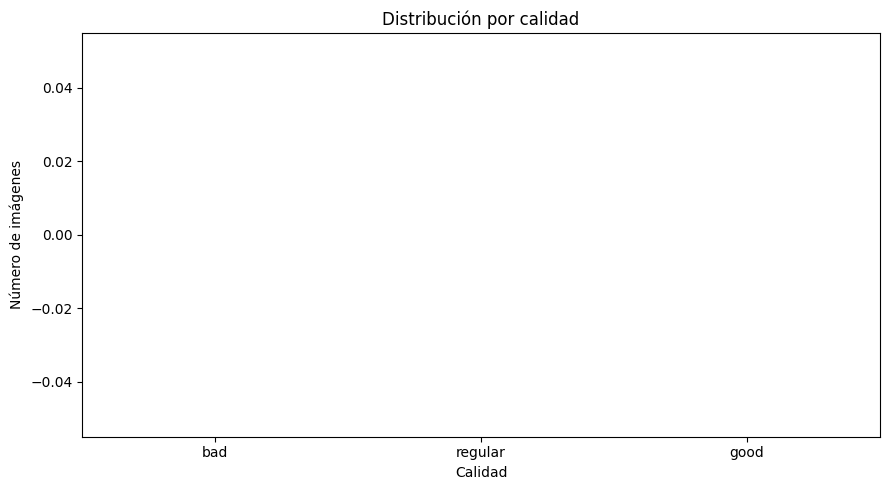

In [7]:
quality_counts = df.groupby("quality_label").size().reindex(QUALITY_LABELS, fill_value=0).reset_index(name="count")
quality_counts["percentage"] = np.where(len(df) > 0, (quality_counts["count"] / len(df) * 100).round(2), 0)

quality_counts_path = tables_dir / "02_quality_distribution.csv"
quality_counts.to_csv(quality_counts_path, index=False, encoding="utf-8")

display(quality_counts)

ax = quality_counts.set_index("quality_label")["count"].plot(kind="bar")
ax.set_title("Distribución por calidad")
ax.set_xlabel("Calidad")
ax.set_ylabel("Número de imágenes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / "01_distribucion_calidad.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Distribución por fruta

Este análisis permite revisar si el dataset tiene suficientes ejemplos de cada fruta y si hay frutas que todavía requieren más recolección.


,fruit_type,count,percentage
0,apple,0,0.0
1,banana,0,0.0
2,guava,0,0.0
3,lemon,0,0.0
4,lime,0,0.0
5,orange,0,0.0
6,pomegranate,0,0.0


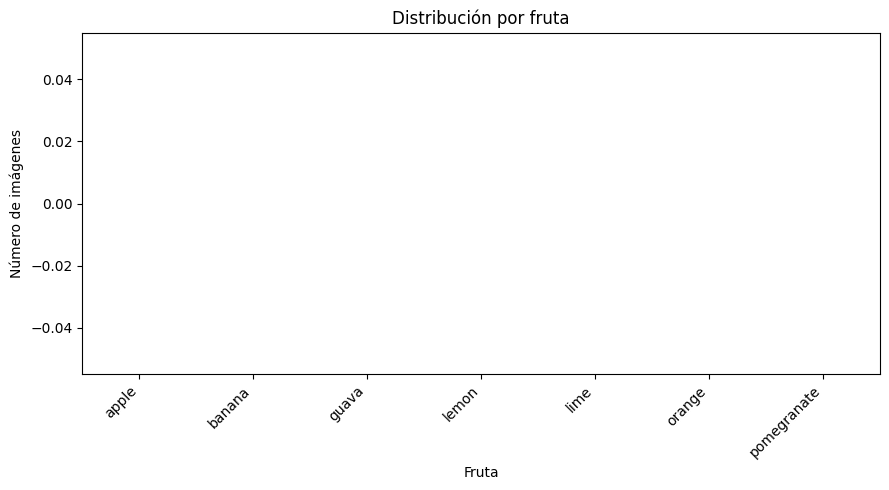

In [8]:
fruit_counts = df.groupby("fruit_type").size().reindex(FRUIT_TYPES, fill_value=0).reset_index(name="count")
fruit_counts["percentage"] = np.where(len(df) > 0, (fruit_counts["count"] / len(df) * 100).round(2), 0)

fruit_counts_path = tables_dir / "03_fruit_distribution.csv"
fruit_counts.to_csv(fruit_counts_path, index=False, encoding="utf-8")

display(fruit_counts)

ax = fruit_counts.set_index("fruit_type")["count"].plot(kind="bar")
ax.set_title("Distribución por fruta")
ax.set_xlabel("Fruta")
ax.set_ylabel("Número de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "02_distribucion_fruta.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Cruce fruta-calidad

Aquí verificamos la cobertura de combinaciones entre fruta y calidad. Las celdas con cero indican material faltante para completar el dataset.


quality_label,bad,regular,good
fruit_type,,,
apple,0,0,0
banana,0,0,0
guava,0,0,0
lemon,0,0,0
lime,0,0,0
orange,0,0,0
pomegranate,0,0,0


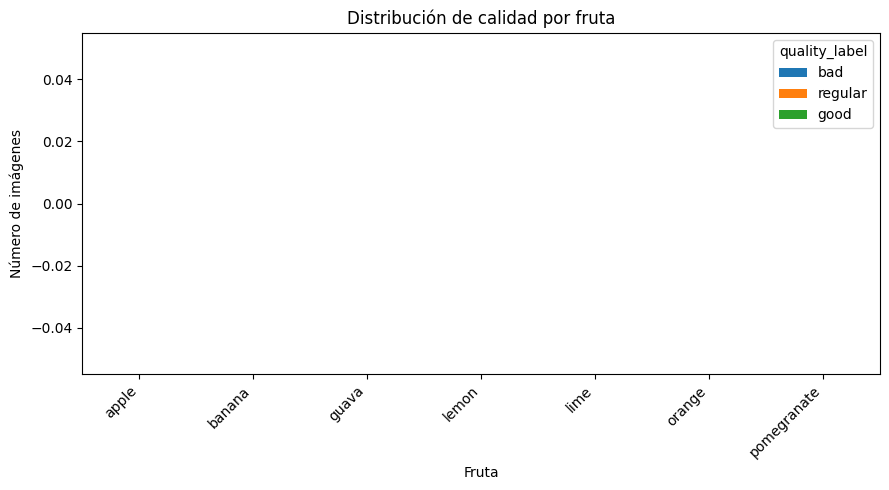

In [9]:
quality_fruit_table = pd.crosstab(df["fruit_type"], df["quality_label"])
quality_fruit_table = quality_fruit_table.reindex(index=FRUIT_TYPES, columns=QUALITY_LABELS, fill_value=0)

quality_fruit_path = tables_dir / "04_quality_by_fruit.csv"
quality_fruit_table.to_csv(quality_fruit_path, encoding="utf-8")

display(quality_fruit_table)

ax = quality_fruit_table.plot(kind="bar")
ax.set_title("Distribución de calidad por fruta")
ax.set_xlabel("Fruta")
ax.set_ylabel("Número de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "03_cruce_fruta_calidad.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Dimensiones de imagen

El EDA no redimensiona imágenes finales. En esta etapa solo verificamos si las imágenes ya llegan cuadradas y si tienen dimensiones razonables para que el notebook 02 las lleve a `TARGET_IMAGE_SIZE x TARGET_IMAGE_SIZE`.


In [10]:
dimension_columns = ["width", "height", "aspect_ratio", "file_size_kb"]
dimension_summary = df[dimension_columns].describe().T if len(df) > 0 else pd.DataFrame(columns=["count", "mean", "std", "min", "25%", "50%", "75%", "max"])

dimension_summary_path = tables_dir / "05_dimension_summary.csv"
dimension_summary.to_csv(dimension_summary_path, encoding="utf-8")

display(dimension_summary)

if len(df) > 0:
    plt.figure()
    plt.scatter(df["width"], df["height"], alpha=0.6)
    plt.title("Ancho vs alto")
    plt.xlabel("Ancho en píxeles")
    plt.ylabel("Alto en píxeles")
    plt.tight_layout()
    plt.savefig(figures_dir / "04_dimensiones_ancho_alto.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure()
    df["aspect_ratio"].plot(kind="hist", bins=20)
    plt.title("Distribución de relación de aspecto")
    plt.xlabel("width / height")
    plt.tight_layout()
    plt.savefig(figures_dir / "05_aspect_ratio.png", dpi=150, bbox_inches="tight")
    plt.show()


,count,mean,std,min,25%,50%,75%,max


## 11. Revisión para recorte

Una imagen lista para el flujo de preprocesamiento debe estar centrada, con fondo simple y preferiblemente en relación 1:1. Las imágenes no cuadradas se dejan marcadas para recorte antes de preparar el dataset final.


In [11]:
review_df = df.copy()
review_df["expected_size_after_preprocessing"] = f"{target_image_size}x{target_image_size}"
review_df["review_reason"] = ""
review_df.loc[review_df["requires_crop"], "review_reason"] = review_df.loc[review_df["requires_crop"], "review_reason"] + "requires_square_crop;"
review_df.loc[~review_df["mode"].isin(["RGB", "RGBA"]), "review_reason"] = review_df.loc[~review_df["mode"].isin(["RGB", "RGBA"]), "review_reason"] + "check_color_mode;"
review_df.loc[review_df.duplicated(subset=["image_hash"], keep=False), "review_reason"] = review_df.loc[review_df.duplicated(subset=["image_hash"], keep=False), "review_reason"] + "duplicate_hash;"

image_review = review_df[review_df["review_reason"].str.len() > 0].copy()
image_review_path = annotations_dir / "image_review.csv"
image_review.to_csv(image_review_path, index=False, encoding="utf-8")

print("Imágenes para revisar:", len(image_review))
print("Archivo generado:", image_review_path)
display(image_review[["image_id", "source", "quality_label", "fruit_type", "relative_path", "width", "height", "mode", "review_reason"]].head(30))


Imágenes para revisar: 0
Archivo generado: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\image_review.csv


,image_id,source,quality_label,fruit_type,relative_path,width,height,mode,review_reason


## 12. Duplicados exactos

Los duplicados los calculamos por hash del archivo. Si aparecen, conviene retirar copias repetidas antes del entrenamiento para evitar que la misma imagen termine en particiones diferentes.


In [12]:
duplicate_images = df[df.duplicated(subset=["image_hash"], keep=False)].sort_values("image_hash")
duplicate_images_path = annotations_dir / "duplicate_images.csv"
duplicate_images.to_csv(duplicate_images_path, index=False, encoding="utf-8")

print("Duplicados exactos:", len(duplicate_images))
print("Archivo generado:", duplicate_images_path)
display(duplicate_images[["image_hash", "source", "quality_label", "fruit_type", "relative_path"]].head(30))


Duplicados exactos: 0
Archivo generado: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\duplicate_images.csv


,image_hash,source,quality_label,fruit_type,relative_path


## 13. Muestra visual

Mostramos una muestra pequeña para revisar visualmente si las etiquetas corresponden con el contenido de las imágenes.


In [13]:
if len(df) > 0:
    sample_df = df.groupby(["quality_label", "fruit_type"], group_keys=False).sample(n=1, random_state=RANDOM_STATE)
    sample_df = sample_df.head(12).reset_index(drop=True)

    cols = 4
    rows = int(np.ceil(len(sample_df) / cols))
    plt.figure(figsize=(cols * 3, rows * 3))

    for idx, row in sample_df.iterrows():
        image_path = project_dir / row["relative_path"]
        with Image.open(image_path) as image:
            image = ImageOps.exif_transpose(image).convert("RGB")

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(image)
        plt.title(f"{row['quality_label']} | {row['fruit_type']}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(figures_dir / "06_muestra_visual.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Aún no hay imágenes para visualizar.")


Aún no hay imágenes para visualizar.


## 14. Salidas generadas

El EDA deja archivos reutilizables para el siguiente notebook. `labels.csv` es la entrada principal para preprocesamiento, partición y modelamiento.


In [14]:
outputs = pd.DataFrame({
    "archivo": [
        "data/annotations/labels.csv",
        "data/annotations/image_review.csv",
        "data/annotations/duplicate_images.csv",
        "results/tables/01_folder_inventory.csv",
        "results/tables/02_quality_distribution.csv",
        "results/tables/03_fruit_distribution.csv",
        "results/tables/04_quality_by_fruit.csv",
        "results/tables/05_dimension_summary.csv"
    ],
    "uso": [
        "Anotaciones principales del dataset",
        "Imágenes que requieren revisión antes del preprocesamiento",
        "Duplicados exactos detectados por hash",
        "Inventario de carpetas esperadas",
        "Balance de la variable objetivo",
        "Cobertura por fruta",
        "Cobertura por fruta y calidad",
        "Resumen de dimensiones y tamaño de archivo"
    ]
})

display(outputs)


,archivo,uso
0,data/annotations/labels.csv,Anotaciones principales del dataset
1,data/annotations/image_review.csv,Imágenes que requieren revisión antes del preprocesamiento
2,data/annotations/duplicate_images.csv,Duplicados exactos detectados por hash
3,results/tables/01_folder_inventory.csv,Inventario de carpetas esperadas
4,results/tables/02_quality_distribution.csv,Balance de la variable objetivo
5,results/tables/03_fruit_distribution.csv,Cobertura por fruta
6,results/tables/04_quality_by_fruit.csv,Cobertura por fruta y calidad
7,results/tables/05_dimension_summary.csv,Resumen de dimensiones y tamaño de archivo
